# 🎮 💡 🛠️ Annotated Transformer practical

- Material adapted from [The Annotated Transformer](https://nlp.seas.harvard.edu/2018/04/03/attention.html)
- Harvard SEAS resource on teaching transformers

## Install packages

In [18]:
# !pip install http://download.pytorch.org/whl/cu80/torch-0.3.0.post4-cp36-cp36m-linux_x86_64.whl numpy matplotlib spacy torchtext seaborn

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn
seaborn.set_context(context="talk")
%matplotlib inline

## Model Architecture

- Most competitive neural sequence transduction models have an encoder-decoder structure (cite).
- Here, the encoder maps an input sequence of symbol representations to a sequence of continuous representations
- Given z, the decoder then generates an output sequence of symbols one element at a time.
- At each step the model is auto-regressive (cite), consuming the previously generated symbols as additional input when generating the next.

In [20]:
class EncoderDecoder(nn.Module):
    """
    A standard Encoder-Decoder architecture. Base for this and many
    other models.
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask,
                            tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [21]:
class Generator(nn.Module):
    "Define standard linear + softmax generation step."
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively.

In [22]:
## Encoder and decoders

### Encoder

In [23]:
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

class Encoder(nn.Module):
    "Core encoder is a stack of N layers"
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

We employ a residual connection (cite) around each of the two sub-layers, followed by layer normalization (cite).



In [24]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2


- That is, the output of each sub-layer is
 where  is the function implemented by the sub-layer itself. We apply dropout (cite) to the output of each sub-layer, before it is added to the sub-layer input and normalized.

- To facilitate these residual connections, all sub-layers in the model, as well as the embedding layers, produce outputs of dimension
d model = 512
.

In [25]:
class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))


Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-wise fully connected feed- forward network.



In [26]:
class EncoderLayer(nn.Module):
    "Encoder is made up of self-attn and feed forward (defined below)"
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        "Follow Figure 1 (left) for connections."
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)


## Decoder

- The decoder is also composed of a stack of $N$ = 6 identical layers


In [27]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

- In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization.


In [28]:
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

- We also modify the self-attention sub-layer in the decoder stack to prevent positions from attending to subsequent positions. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position  can depend only on the known outputs at positions less than


### `subsequent_mask` function:

*   **`def subsequent_mask(size):`**: This line defines a Python function called `subsequent_mask` that takes one argument, `size`. This function is designed to create a triangular mask, often used in Transformer models to prevent attention to future positions in a sequence.

*   **`"Mask out subsequent positions."`**: This is a docstring, a brief explanation of what the function does.

*   **`attn_shape = (1, size, size)`**: This creates a tuple `attn_shape` which defines the dimensions of the attention mask. It's typically `(batch_size, sequence_length, sequence_length)`. Here, `1` is used as a placeholder for the batch size, and `size` represents the sequence length for both the query and key dimensions of the attention matrix.

*   **`subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')`**: This is the core of the mask creation:
    *   `np.ones(attn_shape)`: Creates a 3D NumPy array filled with ones, with the shape defined by `attn_shape` (e.g., if `size` is 5, it would be a 1x5x5 array of ones).
    *   `np.triu(..., k=1)`: This function extracts the upper triangular part of the array, setting all other elements to zero. The `k=1` argument means that the main diagonal *and* everything below it is set to zero. This effectively masks out positions that are equal to or come *after* the current position. For example, in a 5x5 matrix, the element at (0,0) would be 1, but (0,1), (0,2) etc. would be 0, effectively preventing the first token from attending to itself or any subsequent tokens.
    *   `.astype('uint8')`: Converts the data type of the NumPy array to `uint8` (unsigned 8-bit integer).

*   **`return torch.from_numpy(subsequent_mask) == 0`**: This line converts the NumPy mask into a PyTorch tensor and inverts its boolean values:
    *   `torch.from_numpy(subsequent_mask)`: Converts the NumPy array `subsequent_mask` into a PyTorch tensor.
    *   `== 0`: This performs an element-wise comparison. Since `np.triu(..., k=1)` set the lower triangle and diagonal to zeros and the upper triangle to ones, this comparison will result in `True` for the positions that were originally `0` (which are the positions we *want* to allow attention to, i.e., previous and current tokens if `k=0` was used, but here it's `k=1`, so only previous tokens) and `False` for the positions that were `1` (which are the subsequent positions we want to mask out). This creates a boolean mask where `False` typically indicates positions that should be ignored or masked

In [29]:
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
    return torch.from_numpy(subsequent_mask) == 0



An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum of the values, where the weight assigned to each value is computed by a compatibility function of the query with the corresponding key.

We call our particular attention “Scaled Dot-Product Attention”. The input consists of queries and keys of dimension $d_k$, and values of dimension $d_v$. We compute the dot products of the query with all keys, divide each by $\sqrt{d_k}$, and apply a softmax function to obtain the weights on the values.

In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix $Q$. The keys and values are also packed together into matrices $K$ and $V$. We compute the matrix of outputs as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

When we say "in practice, we compute the attention function on a set of queries simultaneously," it means that instead of processing one query at a time, we group multiple queries together into a single matrix. This is a common optimization in deep learning to leverage matrix multiplication capabilities of hardware like GPUs.

Here's a breakdown of the components and the formula:

*   **Queries, Keys, and Values as Matrices ($Q, K, V$)**:
    *   Instead of individual vectors for a single query, key, or value, we now have matrices where each row represents a distinct query, key, or value vector from a sequence. For example, if you have a sequence of length `L` and each vector has dimension `d_k`, then $Q$ would be an `L x d_k` matrix. Similarly, $K$ would be `L x d_k` and $V$ would be `L x d_v`.

*   **The Formula: $\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$**

    1.  **$QK^T$ (Query-Key Dot Product Scores)**:
        *   This is the core of the compatibility function. The matrix multiplication of $Q$ (queries) and $K^T$ (transpose of keys) results in a score matrix. If $Q$ is `(batch_size, num_queries, d_k)` and $K$ is `(batch_size, num_keys, d_k)`, then $K^T$ is `(batch_size, d_k, num_keys)`. The product $QK^T$ will have dimensions `(batch_size, num_queries, num_keys)`. Each element $(i, j)$ in this resulting matrix represents the dot product similarity between the $i$-th query and the $j$-th key.

    2.  **Scaling by $\frac{1}{\sqrt{d_k}}$**:
        *   The dot products can grow large in magnitude as the dimension $d_k$ increases, pushing the softmax function into regions where it has extremely small gradients, which can hinder training. Dividing by the square root of $d_k$ (the dimension of the keys) helps to counteract this effect, keeping the variance of the dot products more consistent.

    3.  **$\text{softmax}(\dots)$ (Obtaining Attention Weights)**:
        *   The softmax function is applied row-wise to the scaled score matrix. This normalizes the scores for each query such that they sum to 1. The result is a matrix of attention weights, where each row indicates how much attention a particular query should pay to each of the keys.

    4.  **Multiplying by $V$ (Weighted Sum of Values)**:
        *   Finally, this matrix of attention weights is multiplied by the value matrix $V$. If the attention weights matrix is `(batch_size, num_queries, num_keys)` and $V$ is `(batch_size, num_keys, d_v)`, the result is an output matrix of dimensions `(batch_size, num_queries, d_v)`. Each row in this output matrix is a weighted sum of the value vectors, where the weights are determined by the attention mechanism. This effectively means that for each query, we get an output vector that is a combination of the input values, weighted by their relevance to that specific query.

In [30]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) \
             / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = F.softmax(scores, dim = -1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn


The two most commonly used attention functions are additive attention (cite), and dot-product (multiplicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor of $\frac{1}{\sqrt{d_k}}$. Additive attention computes the compatibility function using a feed-forward network with a single hidden layer. While the two are similar in theoretical complexity, dot-product attention is much faster and more space-efficient in practice, since it can be implemented using highly optimized matrix multiplication code.

While for small values of $d_k$ the two mechanisms perform similarly, additive attention outperforms dot product attention without scaling for larger values of $d_k$ (cite). We suspect that for large values of $d_k$, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients (To illustrate why the dot products get large, assume that the components of $q$ and $k$ are independent random variables with mean $0$ and variance $1$. Then their dot product, $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$, has mean $0$ and variance $d_k$). To counteract this effect, we scale the dot products by $\frac{1}{\sqrt{d_k}}$.

### Explanation of the Demonstration:

This Python code simulates the dot product behavior for varying dimensions ($d_k$):

1.  **Vector Generation**: For each `d_k` value, it creates `num_samples` pairs of vectors, `q` and `k`. Each component of these vectors is sampled from a standard normal distribution (mean 0, variance 1), mimicking the assumption made in the text.

2.  **Unscaled Dot Product**: It calculates the dot product for each pair of `q` and `k` vectors. As predicted, the mean of the dot products stays close to 0, but their standard deviation (and thus the magnitude) increases with $d_k$. This is because the sum of $d_k$ independent random variables (each $q_i k_i$ has variance 1 if $q_i, k_i$ have variance 1) has a variance of $d_k$. The standard deviation is $\sqrt{d_k}$.

3.  **Scaled Dot Product**: It then divides each dot product by $\sqrt{d_k}$. You will observe that both the mean and standard deviation of these *scaled* dot products remain relatively constant (around 0 and 1, respectively), regardless of $d_k$. This demonstrates how scaling effectively stabilizes the variance of the dot products.

**Visual Interpretation**: The plots clearly show the divergence of unscaled dot product magnitudes as $d_k$ increases, while the scaled dot products remain within a much narrower and stable range. This stability is crucial for the softmax function, as extremely large or small inputs can lead to vanishing gradients during training.

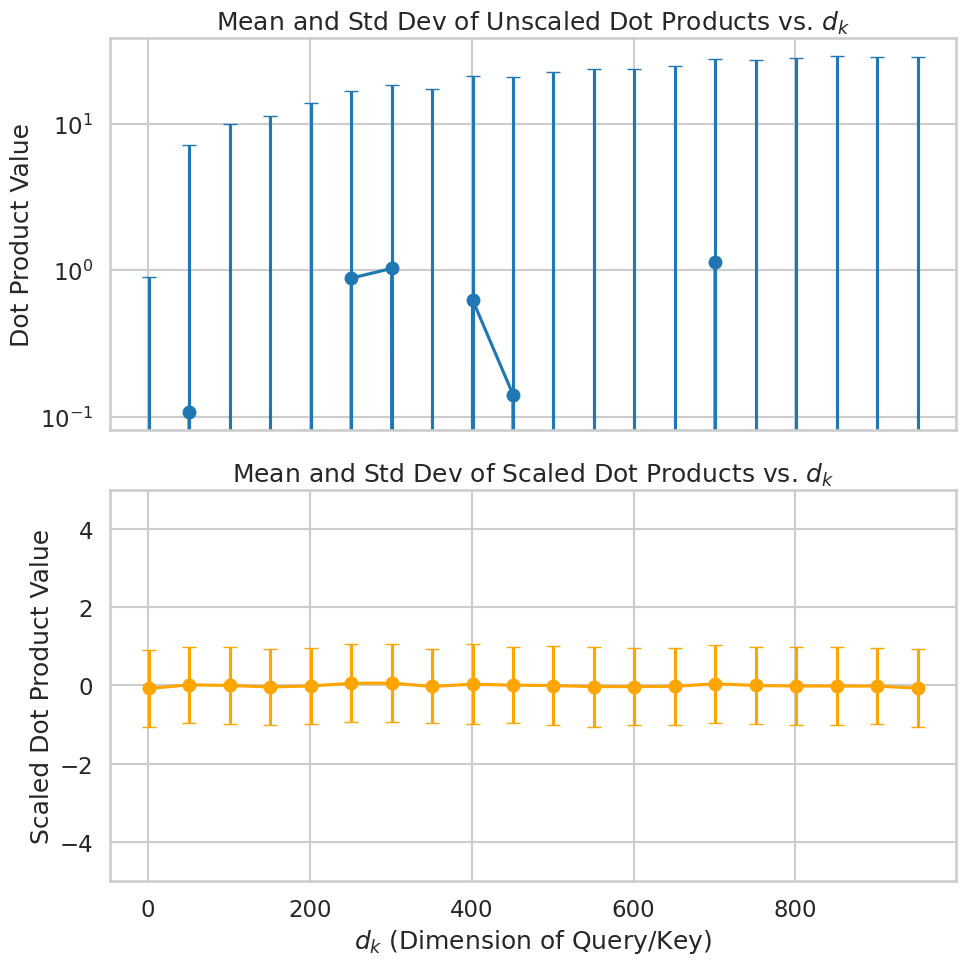

In [31]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import math # Added this line

sns.set_style("whitegrid")

def demonstrate_dot_product_scaling(max_dk=1000, num_samples=1000):
    dk_values = list(range(1, max_dk + 1, 50))
    unscaled_dot_products_mean = []
    unscaled_dot_products_std = []
    scaled_dot_products_mean = []
    scaled_dot_products_std = []

    for dk in dk_values:
        # Generate q and k components with mean 0 and variance 1
        # For simplicity, using torch.randn which produces samples from N(0, 1)
        q = torch.randn(num_samples, dk)
        k = torch.randn(num_samples, dk)

        # Calculate dot product: q * k sum over dk dimension
        # torch.sum(q * k, dim=1) gives a vector of dot products for each sample
        dot_products = torch.sum(q * k, dim=1)
        unscaled_dot_products_mean.append(torch.mean(dot_products).item())
        unscaled_dot_products_std.append(torch.std(dot_products).item())

        # Apply scaling
        scaled_dot_products = dot_products / math.sqrt(dk)
        scaled_dot_products_mean.append(torch.mean(scaled_dot_products).item())
        scaled_dot_products_std.append(torch.std(scaled_dot_products).item())

    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Plot for unscaled dot products
    axes[0].errorbar(dk_values, unscaled_dot_products_mean, yerr=unscaled_dot_products_std, fmt='-o', capsize=5)
    axes[0].set_title('Mean and Std Dev of Unscaled Dot Products vs. $d_k$')
    axes[0].set_ylabel('Dot Product Value')
    axes[0].set_yscale('log') # Use log scale to better show the increase
    axes[0].grid(True)

    # Plot for scaled dot products
    axes[1].errorbar(dk_values, scaled_dot_products_mean, yerr=scaled_dot_products_std, fmt='-o', capsize=5, color='orange')
    axes[1].set_title('Mean and Std Dev of Scaled Dot Products vs. $d_k$')
    axes[1].set_xlabel('$d_k$ (Dimension of Query/Key)')
    axes[1].set_ylabel('Scaled Dot Product Value')
    axes[1].grid(True)
    axes[1].set_ylim([-5, 5]) # Keep y-axis consistent for scaled values

    plt.tight_layout()
    plt.show()

# Run the demonstration
demonstrate_dot_product_scaling()


### Impact on Softmax Output Distribution:

The plots above demonstrate the effect of scaling on the softmax output probabilities for different values of $d_k$ (the dimension of query/key vectors).

*   **Unscaled Softmax (Red Plots)**:
    *   For small $d_k$ (e.g., $d_k=1$), the distribution of softmax probabilities might be relatively spread out.
    *   However, as $d_k$ increases (e.g., $d_k=64, 512$), the unscaled dot products become larger in magnitude. This pushes the softmax function to produce highly peaked distributions, where one probability is very close to 1 and all others are very close to 0. This is often referred to as a "hard" softmax. In a training scenario, such hard distributions result in extremely small gradients for most of the output, making learning very slow or difficult (vanishing gradients).

*   **Scaled Softmax (Blue Plots)**:
    *   When the dot products are scaled by $\frac{1}{\sqrt{d_k}}$, the magnitudes are kept in a more controlled range.
    *   Consequently, the softmax function produces a "softer" and more distributed set of probabilities, even for larger $d_k$. This means that the model can attend to a wider range of keys, and the gradients for the softmax output will be more stable and less prone to vanishing, facilitating effective learning.

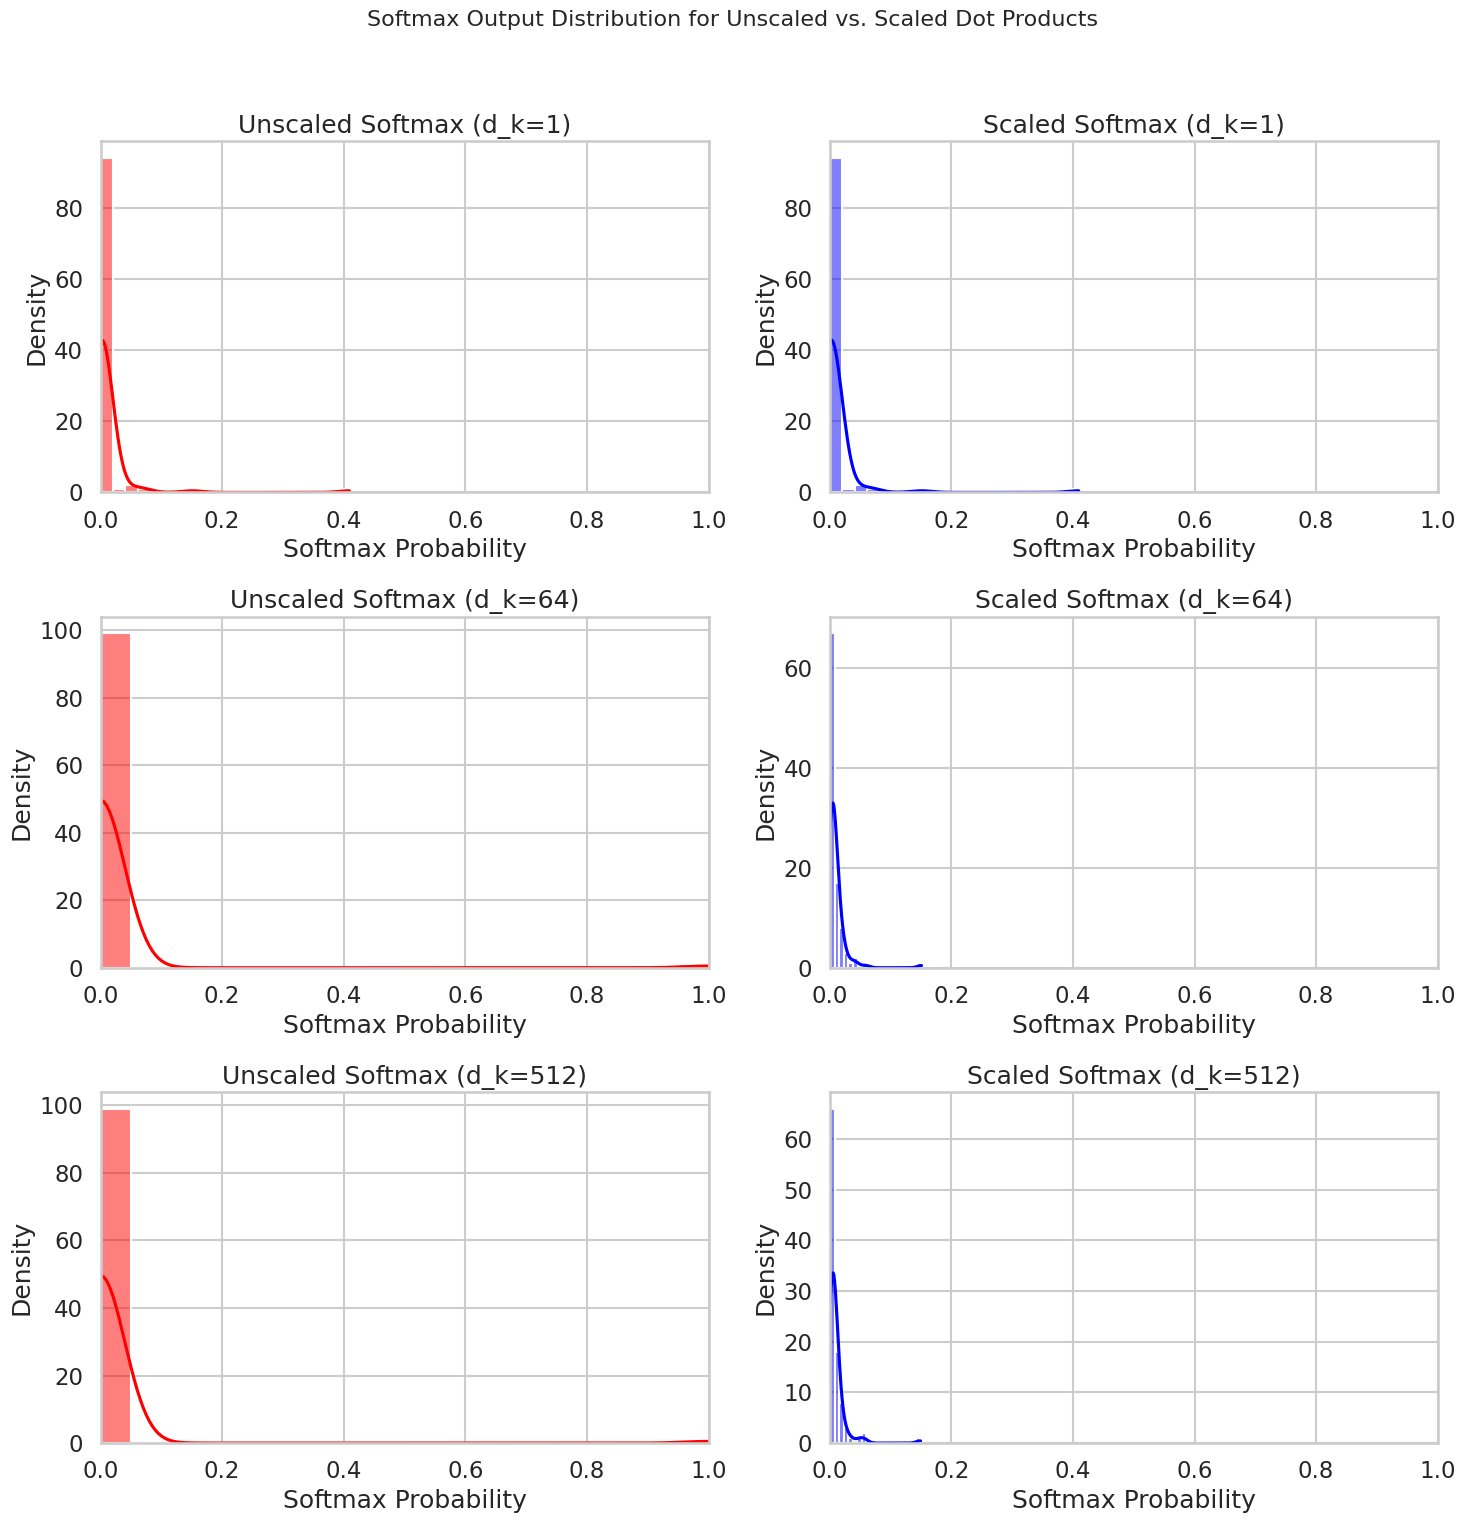

In [32]:
def plot_softmax_distribution(d_k_list=[1, 64, 512]):
    fig, axes = plt.subplots(len(d_k_list), 2, figsize=(15, 5 * len(d_k_list)))
    fig.suptitle('Softmax Output Distribution for Unscaled vs. Scaled Dot Products', fontsize=16, y=1.02)

    for i, dk in enumerate(d_k_list):
        # Generate a single query and a set of keys
        q = torch.randn(1, dk) # Single query vector
        k = torch.randn(100, dk) # 100 key vectors

        # Unscaled dot products
        unscaled_scores = torch.matmul(q, k.transpose(-2, -1)).squeeze(0) # Shape (100,)
        unscaled_softmax = F.softmax(unscaled_scores, dim=-1)

        # Scaled dot products
        scaled_scores = unscaled_scores / math.sqrt(dk)
        scaled_softmax = F.softmax(scaled_scores, dim=-1)

        # Plot unscaled softmax distribution
        sns.histplot(unscaled_softmax.numpy(), ax=axes[i, 0], kde=True, bins=20, color='red')
        axes[i, 0].set_title(f'Unscaled Softmax (d_k={dk})')
        axes[i, 0].set_xlabel('Softmax Probability')
        axes[i, 0].set_ylabel('Density')
        axes[i, 0].set_xlim([0, 1])

        # Plot scaled softmax distribution
        sns.histplot(scaled_softmax.numpy(), ax=axes[i, 1], kde=True, bins=20, color='blue')
        axes[i, 1].set_title(f'Scaled Softmax (d_k={dk})')
        axes[i, 1].set_xlabel('Softmax Probability')
        axes[i, 1].set_ylabel('Density')
        axes[i, 1].set_xlim([0, 1])

    plt.tight_layout()
    plt.show()

plot_softmax_distribution()
